# Baseline of model, introducing of general metrics

## Introduction to metrics, baseline models

Для оценки качества моделей и бейзлайна, буду применять стандартные метрики качества такие как: MAE, RMSE, MAPE, SMAPE

$MAE = \frac{1}{n}\sum_{t=1}^{n}|y_t - \hat{y}_t|$

$RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^n(y_t - \hat{y}_t)^2}$

$MAPE = \frac{100}{n}\sum_{t=1}^{n}|\frac{y_t - \hat{y}_t}{y_t}|$

$SMAPE = \frac{100}{n}\sum_{t=1}^{n}|\frac{2(y_t - \hat{y}_t)|}{|y_t| + |\hat{y}_t|}$

MAE характеризует среднюю величину ошибки, RMSE сильнее штрафует большие ошибки, а MAPE позволяет интерпретировать точность прогноза в процентном выражении.

В качестве базовых моделей прогнозирования (baseline) используются несколько классических методов прогнозирования временных рядов:

**Наивный прогноз (Naive forecast)**

Предполагается, что значение временного ряда в следующий момент времени равно последнему наблюдаемому значению:

$\hat{y}_{t+1} = y_t$

**Seasonal Naive**

$\hat{y}_{t+h} = y_{t+h-s} $

**Экспоненциальное сглаживание**

Метод простого экспоненциального сглаживания позволяет учитывать влияние предыдущих наблюдений с экспоненциально убывающими весами.
Данный метод реализуется в рамках модели Exponential Smoothing.

**Метод Хольта–Уинтерса**

Для временных рядов, содержащих тренд и сезонность, используется тройное экспоненциальное сглаживание — модель Holt-Winters method, которая учитывает:
- уровень ряда
- тренд
- сезонную компоненту.

В качестве горизонта будем прогнозировать на: 1 месяц, квартал, полугодие, год

Проведем эксперименты отдельно по каждой группе (product, market), product (aggregated by store), market (aggregated by products), total (aggregated by date) 

## Prepare

In [22]:
from sklearn.metrics import mean_absolute_percentage_error as mape, mean_absolute_error as mae, root_mean_squared_error as rmse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def smape(y: np.array, y_forecast: np.array) -> float:

    if len(y) != len(y_forecast):
        raise ValueError("y and y_forecast must have the same length")

    denominator = (np.abs(y) + np.abs(y_forecast)) / 2

    diff = np.abs(y - y_forecast) / denominator

    diff[denominator == 0] = 0

    return np.mean(diff) * 100

def evaluate(y, y_hat):

    return {
        "MAE": mae(y, y_hat),
        "RMSE": rmse(y, y_hat),
        "MAPE": mape(y, y_hat),
        "SMAPE": smape(y, y_hat)
    }

In [9]:
data = pd.read_csv('data/data_4_forecast.csv')
data.head(10)

,Unnamed: 0,Row Labels,MKT_SDESC,PER_SDESC,MT_Volume KG,NT_CWD,NT_Avg Line,NT_Price per kg,NT_Universe,MT_Universe percent,...,sales_rolling1_std,sales_rolling3_mean,sales_rolling3_std,sales_rolling6_mean,sales_rolling6_std,sales_rolling12_mean,sales_rolling12_std,NT_CWD_clean,differentiation,NT_CWD_diff
0,0,BAGS,Discounters,2019-01-01,1458414.5,3175.94,31.759400,361.647156,26047.36129,0.126383,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3175.94,1,NaN
1,1,BAGS,Discounters,2019-02-01,1599316.0,3151.74,31.517400,357.873791,26385.74648,0.127194,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3151.74,1,-24.20
2,2,BAGS,Discounters,2019-03-01,1505515.5,3155.40,31.554000,385.256139,26475.00379,0.128160,...,NaN,3161.026667,13.044330,NaN,NaN,NaN,NaN,3155.40,1,3.66
3,3,BAGS,Discounters,2019-04-01,1565605.8,3414.86,34.152015,393.144379,26895.73306,0.129438,...,NaN,3240.666667,150.866951,NaN,NaN,NaN,NaN,3414.86,1,259.46
4,4,BAGS,Discounters,2019-05-01,1508979.0,3394.44,33.944400,404.401652,27153.48617,0.130361,...,NaN,3321.566667,144.266299,NaN,NaN,NaN,NaN,3394.44,1,-20.42
5,5,BAGS,Discounters,2019-06-01,1271805.5,3282.95,32.829500,401.501645,27337.00409,0.135128,...,NaN,3364.083333,71.001461,3262.555000,120.225404,NaN,NaN,3282.95,1,-111.49
6,6,BAGS,Discounters,2019-07-01,1415931.8,3222.57,32.225700,393.357929,27709.80939,0.136254,...,NaN,3299.986667,87.192375,3270.326667,114.895594,NaN,NaN,3222.57,1,-60.38
7,7,BAGS,Discounters,2019-08-01,1504473.5,3075.20,30.752000,388.692735,27994.67277,0.137611,...,NaN,3193.573333,106.867304,3257.570000,133.446777,NaN,NaN,3075.20,1,-147.37
8,8,BAGS,Discounters,2019-09-01,1506278.6,2887.48,28.874800,383.797133,28145.16792,0.138331,...,NaN,3061.750000,167.949409,3212.916667,201.794246,NaN,NaN,2887.48,1,-187.72
9,9,BAGS,Discounters,2019-10-01,1566526.6,2730.77,27.307700,404.944799,28466.71358,0.143768,...,NaN,2897.816667,172.447503,3098.901667,251.909653,NaN,NaN,2730.77,1,-156.71


In [41]:
def ts_split(series, horizon):

    train = series.iloc[:-horizon]
    test = series.iloc[-horizon:]
    return train, test

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

def naive_forecast(train, horizon):

    last_value = train.iloc[-1]
    forecast = np.repeat(last_value, horizon)

    return forecast

def seasonal_naive(train, horizon, season_length=12):

    forecast = train.iloc[-season_length:][:horizon]

    return forecast.values


def ses_forecast(train, horizon):

    model = SimpleExpSmoothing(train).fit()

    forecast = model.forecast(horizon)

    return forecast.values


def hw_forecast(train, horizon):

    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    ).fit()

    forecast = model.forecast(horizon)

    return forecast.values

## Total Sale

In [44]:
horizons = [1,3,6,12]

splits = {}

df = data.groupby('PER_SDESC').agg({'NT_CWD':'sum'})
df.sort_values('PER_SDESC')
for h in horizons:

    train, test = ts_split(df, h)

    key = h

    splits[key] = {
        "train": train,
        "test": test
    }

In [77]:
results = []

for key in splits.keys():

    train_df = splits[key]['train']
    test_df = splits[key]['test']

    h = key
    
    y_train = train_df["NT_CWD"]
    y_train.index = pd.to_datetime(y_train.index)
    y_train = y_train.asfreq('MS')
    
    y_test = test_df["NT_CWD"]
    y_test.index = pd.to_datetime(y_test.index)
    y_test = y_test.asfreq('MS')

    models = {
        "naive": naive_forecast,
        "seasonal_naive": seasonal_naive,
        "ses": ses_forecast,
        "holt_winters": hw_forecast
    }

    for model_name, model in models.items():

        forecast = model(y_train, h)

        metrics = evaluate(y_test.values, forecast)

        metrics["horizon"] = h
        metrics["model"] = model_name
        results.append(metrics)

results = pd.DataFrame(results)

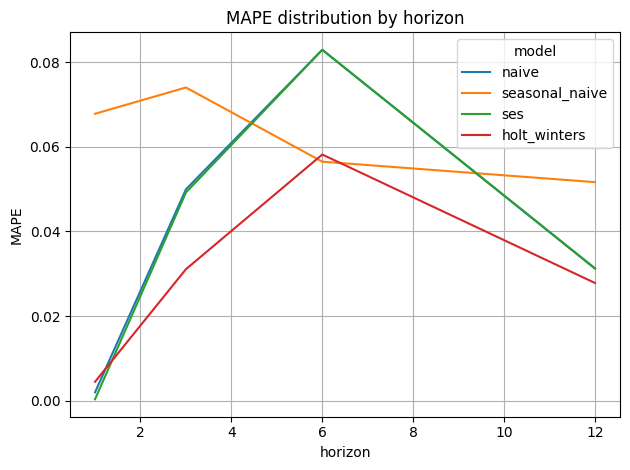

In [84]:
sns.lineplot(results, x = 'horizon', y = 'MAPE', hue='model')
title = 'MAPE distribution by horizon'
plt.title(title)
plt.grid()
plt.tight_layout()
plt.show()

In [51]:
pivot = results.pivot_table(
    index="model",
    columns="horizon",
    values="MAE",
    aggfunc="mean"
)
pivot

horizon,1,3,6,12
model,,,,
holt_winters,792.754834,5565.398405,10578.195508,5150.895726
naive,352.230000,8857.336667,15023.673333,5849.863333
seasonal_naive,11962.680000,13244.790000,10334.243333,9580.288333
ses,64.652554,8721.895247,15023.673256,5862.776765


## Products

## Stores

## Product + Market

In [42]:
horizons = [1,3,6,12]

splits = {}

for (product, market), df in data.groupby(['Row Labels','MKT_SDESC']):

    df = df.sort_values("PER_SDESC")

    for h in horizons:

        train, test = ts_split(df, h)

        key = (product, market, h)

        splits[key] = {
            "train": train,
            "test": test
        }

In [30]:
results = []

for key in splits.keys():

    train_df = splits[key]['train']
    test_df = splits[key]['test']

    product, market, h = key

    y_train = train_df["NT_CWD"]
    y_test = test_df["NT_CWD"]

    models = {
        "naive": naive_forecast,
        "seasonal_naive": seasonal_naive,
        "ses": ses_forecast,
        "holt_winters": hw_forecast
    }

    for model_name, model in models.items():

        forecast = model(y_train, h)

        metrics = evaluate(y_test.values, forecast)

        metrics["product"] = product
        metrics["market"] = market
        metrics["horizon"] = h
        metrics["model"] = model_name

        results.append(metrics)

In [34]:
results = pd.DataFrame(results)

In [37]:
pivot = results.pivot_table(
    index="model",
    columns="horizon",
    values="MAE",
    aggfunc="mean"
)

In [38]:
pivot

horizon,1,3,6,12
model,,,,
holt_winters,176.087087,228.905739,278.287821,260.302429
naive,132.282955,269.712197,365.622727,260.979811
seasonal_naive,368.753636,394.791742,381.772879,349.890833
ses,158.204865,267.042970,362.401445,262.055345
